In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.utils import shuffle

In [ ]:
class ImageCompressor:
    def __init__(self, image_path, n_colors=4):
        self.image_path = image_path
        self.k = n_colors
        self.original_img = self._load_image()
        self.pixels = self.original_img.reshape(-1, 3)
        
    def _load_image(self):
        if not os.path.exists(self.image_path):
            raise FileNotFoundError(f"Cannot find {self.image_path}")
        
        img = cv2.imread(self.image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return np.array(img, dtype=np.float64) / 255.0

    def apply_kmeans(self):
        print(f"Running K-Means (k={self.k})...")
        kmeans = KMeans(n_clusters=self.k, random_state=0).fit(image_array_sample)
        
        labels = kmeans.predict(self.pixels)
        centers = kmeans.cluster_centers_
        
        new_pixels = centers[labels]
        return new_pixels.reshape(self.original_img.shape)

    def apply_hierarchical(self):
        print("Running Hierarchical (Downscaled)...")
        scale = 0.1 
        h, w, _ = self.original_img.shape
        small_img = cv2.resize(self.original_img, (int(w*scale), int(h*scale)))
        flat_small = small_img.reshape(-1, 3)
        
        model = AgglomerativeClustering(n_clusters=self.k)
        labels = model.fit_predict(flat_small)
        
        centers = np.zeros((self.k, 3))
        for i in range(self.k):
            cluster_points = flat_small[labels == i]
            if len(cluster_points) > 0:
                centers[i] = cluster_points.mean(axis=0)
                
        new_pixels = centers[labels]
        return new_pixels.reshape(small_img.shape)

    def visualize(self):
        img_kmeans = self.apply_kmeans()
        img_hierarchical = self.apply_hierarchical()
        
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 3, 1)
        plt.title("Original")
        plt.imshow(self.original_img)
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title(f"K-Means (k={self.k})")
        plt.imshow(img_kmeans)
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.title(f"Hierarchical (Downscaled)")
        plt.imshow(img_hierarchical)
        plt.axis('off')
        
        plt.show()

Running K-Means (k=4)...
Running Hierarchical (Downscaled)...


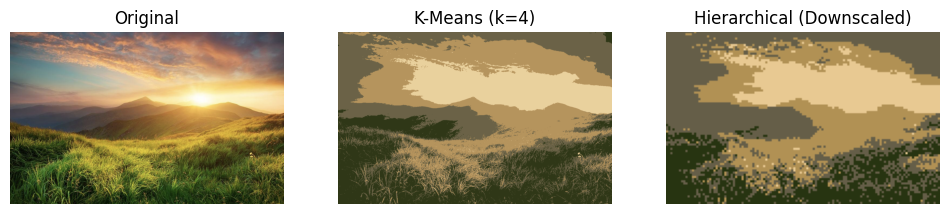

In [10]:

file_path = 'image.png'
compressor = ImageCompressor(file_path, n_colors=4)
compressor.visualize()